# 06 — Evaluation: splitters, metrics, evaluator, plots

Notebook 05 produced a `TrainedBundle` on disk. This notebook works on
that bundle alone — **no training, no warehouse queries** — and walks
through the evaluation surface a downstream notebook
(`inspection/` view, paper recomputation, deployment readiness check)
would use.

## What this notebook contributes

```text
Splitter   (ABC + 5 concrete subclasses)
    name: str                              # configuration identifier
    split(processed) → (train_idx, val_idx)

Metric     (ABC + 7 concrete subclasses)
    name: str                              # column header in score tables
    compute(y_true, y_pred) → float

Evaluator
    score(observed, predictions, splits) → DataFrame
        # one row per (split × prediction); columns: n + each metric

plots      (susse.evaluation.plots)
    plot_predicted_vs_observed_panels(...)
    plot_per_station_metric(...)
    plot_covariate_shift_kde(...)
    plot_feature_importances_top_n(...)
    ...
```

## Three architectural choices reflected here

* **Splitter is a class, not a callable.** It carries its
  configuration in fields so `bundle.metadata.splitter_name` records
  what the val fold actually was — re-running with the same name
  guarantees the same split.
* **Metrics are objects, not free functions.** Each
  :class:`Metric` carries its display name; `Evaluator` composes them
  into a score table without the call site repeating column-header
  strings.
* **Evaluator is the post-training counterpart of
  ``score_predictions``.** That helper produces a single
  :class:`ScoreSet` on one ``(y_true, y_pred)`` pair during training;
  the Evaluator scores many predictions across many splits, post-hoc.

## Notebook structure

| Step | What you'll see |
|---|---|
| 0  | Setup + load the NB 05 bundle + reconstruct its preprocessed dataset |
| 1  | The five concrete splitters — what each one selects |
| 2  | The seven concrete metrics — what each one means and how to read it |
| 3  | The :class:`Evaluator` — one tidy table over splits × predictions |
| 4  | Generic evaluation plots — predicted-vs-observed, per-station MBE, covariate-shift KDEs, feature importances |
| 5  | Where to go next |

### Inputs, outputs, and prerequisites

| | |
|---|---|
| **Inputs**  | The NB 05 bundle at `data/bundles/_nb05_random_forest/` and the matching snapshot at `data/training_snapshots/susse_training_demo_v1-2024/`. |
| **Outputs** | None — this notebook is read-only with respect to artifacts. |
| **Prereqs** | NB 05 must have run successfully (it generates both inputs). If you cloned the repo fresh, run NB 05 first. |
| **Wall time** | Under a minute on a workstation. |

In [1]:
import shutil
import shlex
import sys
import os

PROJECT_ID = "solar-irradiation-estimation"

if "google.colab" in sys.modules:
    # --- GOOGLE COLAB AUTOMATED SETUP ---
    REPO = "Marconi-Lab/Solar_irradiation"
    BRANCH = "jm/add_model"
    clone_url = f"https://github.com{REPO}.git"
    
    if not os.path.exists("/content/Solar_irradiation/.git"):
        get_ipython().system(f"git clone -q -b {BRANCH} {clone_url} /content/Solar_irradiation")

    get_ipython().run_line_magic('cd', '/content/Solar_irradiation')
    get_ipython().system('pip install -q -e . 2>&1 | tail -3')

    from google.colab import auth
    auth.authenticate_user()
    get_ipython().system(f'gcloud config set project {PROJECT_ID} 2>/dev/null')
    print("Colab setup complete.")

else:
    # --- LOCAL WSL / LINUX AUTOMATED SETUP ---
    print("Running in Local Linux/WSL Environment.")
    os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
    
    # 1. Look for gcloud
    gcloud_path = shutil.which("gcloud")
    
    # Fallback check
    if not gcloud_path:
        home_bin = os.path.expanduser("~/google-cloud-sdk/bin/gcloud")
        if os.path.exists(home_bin):
            gcloud_path = home_bin

    # 2. Prevent installing if already found
    if not gcloud_path:
        print("SDK not found anywhere on the system. Installing now...")
        get_ipython().system('curl -sSL https://sdk.cloud.google.com | bash -s -- --disable-prompts > /dev/null')
        gcloud_path = os.path.expanduser("~/google-cloud-sdk/bin/gcloud")
    else:
        print(f"gcloud detected successfully at: {gcloud_path}")

    # FIXED: Use shlex.quote to safely wrap the windows/WSL path strings for Bash
    safe_gcloud_path = shlex.quote(gcloud_path)

    # 3. Trigger authentication using the safe, quoted path
    print("\nOpening your system browser for Google Cloud verification...")
    get_ipython().system(f'{safe_gcloud_path} auth application-default login')
    
    # 4. Set the project configuration
    get_ipython().system(f'{safe_gcloud_path} config set project {PROJECT_ID} 2>/dev/null')
    print(f"\nLocal setup complete! Active project set to: {PROJECT_ID}")

Running in Local Linux/WSL Environment.
gcloud detected successfully at: /mnt/c/Program Files (x86)/Google/Cloud SDK/google-cloud-sdk/bin/gcloud

Opening your system browser for Google Cloud verification...
Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=Ppb8gdwPIrHc70JV2ToAj4ASQErDVf&access_type=offline&code_challenge=KsVbj-0wrVK8AszUlHHbd70HClBoWhr5NY7LUlKbOjk&code_challenge_method=S256

gio: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.goo

## 0 — Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_HERE = Path.cwd().resolve()
_PROJECT_ROOT = _HERE
while _PROJECT_ROOT != _PROJECT_ROOT.parent and not (_PROJECT_ROOT / "src" / "susse").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
sys.path.insert(0, str(_PROJECT_ROOT / "src"))

print(f"project root: {_PROJECT_ROOT}")

project root: /home/mukiibi/Github/SolarIrradiation


### Load the NB 05 bundle + reconstruct its preprocessed dataset

The bundle gives us the trained regressor and the `FeatureSpec` that
produced its inputs. Re-applying the same `Preprocessor` to the
matching snapshot yields the very dataset NB 05 trained on — without
re-training, and without the warehouse.

NB 05's `FeatureSpec.id_columns` doesn't include `lat` / `lon` (it
didn't need them for station-LOSO), so we enrich `processed.df` with
the station coordinates from the raw dataset before exercising the
spatial splitters in §1. This is the pattern to use whenever a
bundle's frozen `FeatureSpec` is missing an id column you need
downstream — copy the column over, don't rebuild the bundle.

In [3]:
from susse.datasets import load_snapshot
from susse.preprocessing import Preprocessor
from susse.training import load_bundle

SNAPSHOT_DIR = (_PROJECT_ROOT / "data" / "training_snapshots"
                / "susse_training_demo_v1-2024").resolve()
BUNDLE_DIR = (_PROJECT_ROOT / "data" / "bundles"
              / "_nb05_random_forest").resolve()
for path in (SNAPSHOT_DIR, BUNDLE_DIR):
    assert path.exists(), (
        f"Missing input: {path}\n"
        f"Run notebooks/tutorial/05_training.ipynb to generate it, "
        f"then come back."
    )

dataset = load_snapshot(SNAPSHOT_DIR)
bundle = load_bundle(BUNDLE_DIR)
processed = Preprocessor(bundle.feature_spec).apply(dataset)

# Enrich with per-station coordinates from the raw dataset so the
# spatial splitters in §1 can find lat/lon. The map is one-to-one on
# `location`; pandas .map fills NaN where the key is unknown (no
# rows in this dataset, so no NaN).
station_coords = dataset.df.drop_duplicates(subset="location").set_index(
    "location"
)[["lat", "lon"]]
processed.df["lat"] = processed.df["location"].map(station_coords["lat"])
processed.df["lon"] = processed.df["location"].map(station_coords["lon"])

print(f"Bundle:        {BUNDLE_DIR.name}")
print(f"Held-out station (NB 05 splitter): "
      f"{bundle.metadata.splitter_name}")
print(f"Processed:     {processed.n_rows:,} rows × "
      f"{processed.n_features} features  "
      f"({processed.df['location'].nunique()} stations)")

Bundle:        _nb05_random_forest
Held-out station (NB 05 splitter): station_loso[kenya_location13]
Processed:     6,776 rows × 9 features  (21 stations)


## 1 — The five concrete splitters

Every concrete splitter implements the same `(name, split)` surface:

```text
class Splitter(ABC):
    @property def name(self) -> str: ...
    def split(processed) -> (train_idx, val_idx)
```

Five strategies cover the common evaluation scenarios:

| Splitter | What it answers |
|---|---|
| `RandomSplitter` | "Does the model fit the joint distribution?" — weakest baseline. |
| `TemporalSplitter` | "Does the model generalise *forward in time*?" |
| `StationLOSOSplitter` | "Does the model generalise to *one new station*?" |
| `SpatialSpreadHoldoutSplitter` | "Does the model generalise to the *most spatially distant* stations?" |
| `SpatialBlockSplitter` | "Does the model generalise across a *known categorical boundary*?" (country, climate zone, …) |

The cell below applies each one in turn to the NB 05 dataset and
prints the resulting fold sizes.

In [4]:
from susse.training import (
    RandomSplitter,
    SpatialBlockSplitter,
    SpatialSpreadHoldoutSplitter,
    StationLOSOSplitter,
    TemporalSplitter,
)


def describe(splitter, processed) -> None:
    train_idx, val_idx = splitter.split(processed)
    train_stations = processed.df.loc[train_idx, "location"].nunique()
    val_stations = processed.df.loc[val_idx, "location"].nunique()
    print(
        f"  {splitter.name:55s}  "
        f"train: {len(train_idx):>6,} ({train_stations} stations)   "
        f"val: {len(val_idx):>6,} ({val_stations} stations)"
    )


# RandomSplitter — 80/20 shuffle. Note: rows from the same station
# typically land in both folds, so this is the weakest test.
describe(RandomSplitter(val_fraction=0.2, random_state=42), processed)

# TemporalSplitter — every 2024 row to val (note this dataset may not
# have any 2024 rows depending on the warehouse snapshot used; the
# splitter just reports zero in that case).
describe(TemporalSplitter(split_date=date(2024, 1, 1)), processed)

# StationLOSOSplitter — held-out station = the one NB 05 chose
# (auto_pick_largest), so the fold matches NB 05's exactly.
splitter_loso = StationLOSOSplitter.auto_pick_largest(processed)
describe(splitter_loso, processed)

# SpatialSpreadHoldoutSplitter — the two most distant stations.
describe(SpatialSpreadHoldoutSplitter(n_holdout=2), processed)

# SpatialBlockSplitter — example: hold out the Madagascar-region
# station, whichever one(s) live there. Block column must exist in
# id_columns; in this dataset the natural block is `location` itself.
madagascar_like = [
    loc for loc in processed.df["location"].unique() if "madagascar" in loc
]
if madagascar_like:
    describe(
        SpatialBlockSplitter(
            val_blocks=tuple(madagascar_like), block_column="location",
        ),
        processed,
    )
else:
    print("  (no madagascar-* stations in this snapshot — skipping block-splitter demo)")

  random[val=0.20,seed=42]                                 train:  5,421 (21 stations)   val:  1,355 (21 stations)
  temporal[val>=2024-01-01]                                train:      0 (0 stations)   val:  6,776 (21 stations)
  station_loso[kenya_location13]                           train:  6,142 (20 stations)   val:    634 (1 stations)
  spatial_spread[n=2]                                      train:  6,127 (19 stations)   val:    649 (2 stations)
  spatial_block[val=madagascar_location1,madagascar_location2]  train:  6,127 (19 stations)   val:    649 (2 stations)


## 2 — The seven concrete metrics

Every concrete metric is a frozen, stateless dataclass implementing
`(name, compute)`. Constructing it takes no arguments today; future
variants (different normalisers, different bound conventions) can
land as new subclasses without changing the call site.

| Metric | What it captures | Returns NaN when … |
|---|---|---|
| `RMSE` | Quadratic penalty on errors | Empty after NaN filter |
| `MAE`  | Linear penalty on errors | Empty after NaN filter |
| `R²`   | Fraction of variance explained | `var(y_obs) = 0` |
| `IndexOfAgreement` (Willmott 1981) | Magnitude agreement, bounded [0, 1] | Both series collapse to the same constant |
| `MeanBiasError` | Signed mean offset | Empty after NaN filter |
| `NormalisedRMSE` | RMSE as % of mean(y_obs) | `mean(y_obs) = 0` |
| `NormalisedMAE` | MAE as % of mean(y_obs) | `mean(y_obs) = 0` |

`DEFAULT_METRICS` is the seven-metric tuple in paper-table order.

In [5]:
from susse.evaluation import DEFAULT_METRICS

# Predict over the LOSO val fold so the metrics have a concrete example.
train_idx, val_idx = splitter_loso.split(processed)
y_val = processed.y().loc[val_idx]
y_pred = pd.Series(
    bundle.regressor.predict(processed.X().loc[val_idx]).values,
    index=val_idx,
)

print(f"Held-out station: {splitter_loso.held_out_station!r}  "
      f"(n={len(val_idx)})")
print()
for metric in DEFAULT_METRICS:
    value = metric.compute(y_val, y_pred)
    print(f"  {metric.name:9s} = {value:8.3f}")

Held-out station: 'kenya_location13'  (n=634)

  RMSE      =    0.597
  nRMSE_%   =   12.773
  MAE       =    0.371
  nMAE_%    =    7.949
  MBE       =    0.181
  R²        =    0.857
  IOA       =    0.960


## 3 — The Evaluator

The Evaluator builds a tidy `(split × prediction)` score table over
its configured metrics in one call. The default metric tuple is
`DEFAULT_METRICS`; pass a different tuple to focus on specific
metrics.

This cell compares the trained RF against the raw NASA + CAMS
satellite estimates on three different splits — illustrating both the
"prediction series" and "split" axes.

In [6]:
from susse.evaluation import Evaluator

# Three named predictions we want to compare.
predictions = {
    "RF":   y_pred,
    "NASA": processed.df.loc[val_idx, "sat_ghi_nasa_kwh_m2_day"],
    "CAMS": processed.df.loc[val_idx, "sat_ghi_cams_kwh_m2_day"],
}

# Three named splits over the *val* fold for a finer-grained look.
held_out_df = processed.df.loc[val_idx]
splits = {
    "all val rows":   val_idx,
    "2023+ only":     held_out_df.index[
                          pd.to_datetime(held_out_df["date"]).dt.year >= 2023
                      ],
    "first half-year": val_idx[: len(val_idx) // 2],
}

table = Evaluator().score(
    observed=y_val, predictions=predictions, splits=splits,
)
table.round(3)

,split,prediction,n,RMSE,nRMSE_%,MAE,nMAE_%,MBE,R²,IOA
0,all val rows,RF,634,0.597,12.773,0.371,7.949,0.181,0.857,0.960
1,all val rows,NASA,634,1.336,28.599,1.037,22.203,0.845,0.284,0.790
2,all val rows,CAMS,634,1.231,26.337,0.981,21.003,0.959,0.393,0.865
3,2023+ only,RF,634,0.597,12.773,0.371,7.949,0.181,0.857,0.960
4,2023+ only,NASA,634,1.336,28.599,1.037,22.203,0.845,0.284,0.790
5,2023+ only,CAMS,634,1.231,26.337,0.981,21.003,0.959,0.393,0.865
6,first half-year,RF,317,0.611,10.995,0.305,5.490,-0.023,0.821,0.947
7,first half-year,NASA,317,0.938,16.877,0.657,11.831,0.314,0.577,0.846
8,first half-year,CAMS,317,0.998,17.967,0.726,13.075,0.686,0.521,0.886


## 4 — Generic evaluation plots

Each of these helpers lives in `susse.evaluation.plots`. Inputs are
plain DataFrames / column names — no library-specific value objects —
so the same calls work in `inspection/` notebooks and in
`papers/<paper>/` validation flows without rewrites.

Five plots in display order:

1. Predicted-vs-observed scatter, one panel per named prediction
2. Per-station metric bar chart, with optional categorical highlight
3. Covariate-shift KDEs — training vs. inference feature distributions
4. Feature importances (top-N)
5. Training-fit time-series — observed + named comparison series, weekly-resampled

All five plots are visual; the figures appear inline when this
notebook is run.

In [7]:
from susse.evaluation import MeanBiasError
from susse.evaluation.plots import (
    plot_covariate_shift_kde,
    plot_feature_importances_top_n,
    plot_per_station_metric,
    plot_predicted_vs_observed_panels,
    plot_training_fit_timeseries,
)

# Build one tidy DataFrame to feed the per-row plots.
val_df = processed.df.loc[val_idx].copy()
val_df["y_pred"] = y_pred
val_df["seen_in_training"] = False  # only the LOSO station is in val
all_df = processed.df.copy()
all_df["y_pred"] = pd.Series(
    bundle.regressor.predict(processed.X()).values, index=processed.df.index
)
all_df["seen_in_training"] = (
    all_df["location"] != splitter_loso.held_out_station
)

### Predicted vs observed — one panel per prediction series

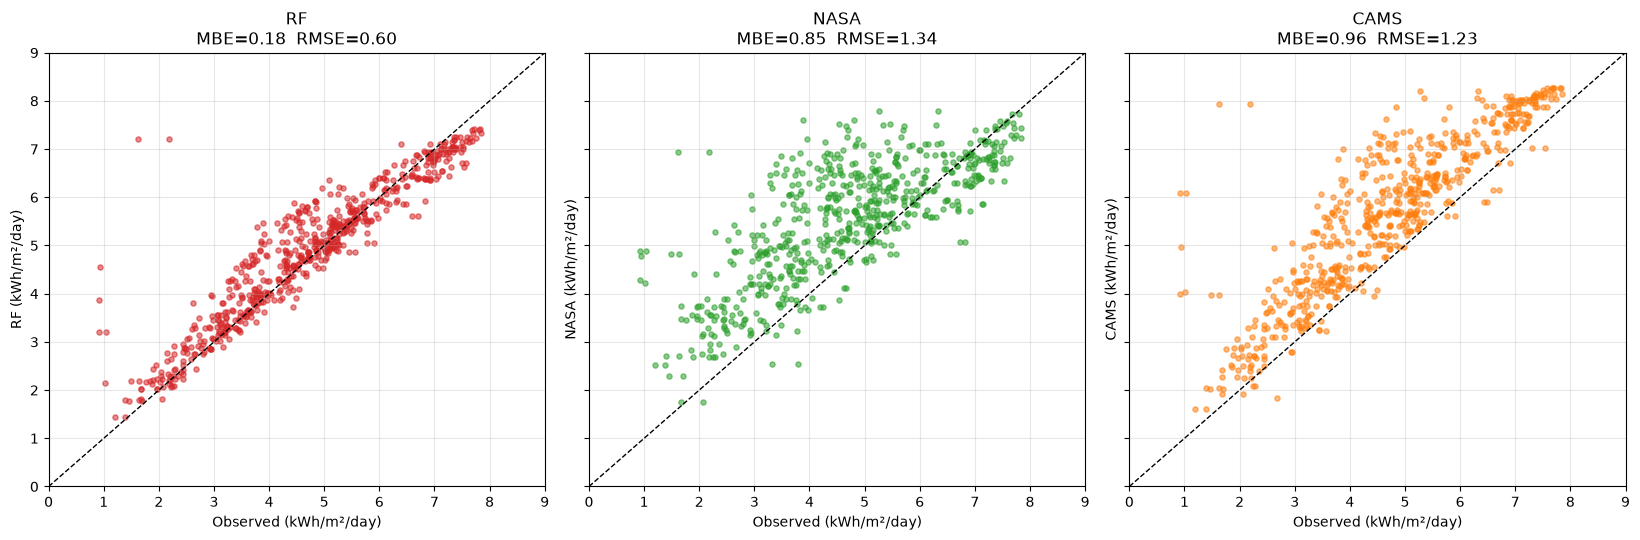

In [8]:
plot_predicted_vs_observed_panels(
    val_df,
    observed_column="y_ghi_kwh_m2_day",
    predictions={
        "RF":   "y_pred",
        "NASA": "sat_ghi_nasa_kwh_m2_day",
        "CAMS": "sat_ghi_cams_kwh_m2_day",
    },
)

### Per-station metric bar chart

Bars sorted by metric value. `highlight_column` lets you mark a
boolean attribute — here we colour each station by whether its rows
went into training (the LOSO station is the only one that didn't, so
all bars but one are highlighted).

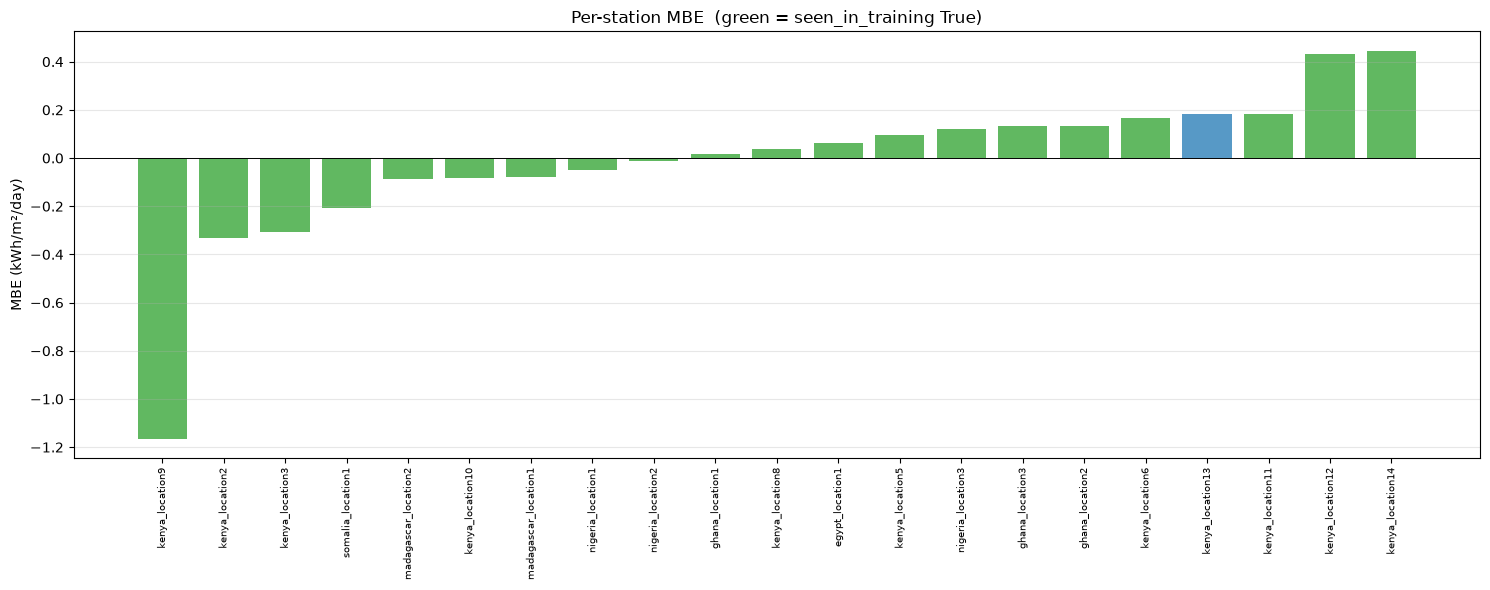

Worst (highest MBE):
                    MBE  _highlight
location                           
kenya_location6   0.165        True
kenya_location13  0.181       False
kenya_location11  0.183        True
kenya_location12  0.434        True
kenya_location14  0.446        True

Best (lowest MBE):
                        MBE  _highlight
location                               
kenya_location9      -1.166        True
kenya_location2      -0.332        True
kenya_location3      -0.307        True
somalia_location1    -0.208        True
madagascar_location2 -0.085        True


In [9]:
plot_per_station_metric(
    all_df,
    observed_column="y_ghi_kwh_m2_day",
    predicted_column="y_pred",
    metric=MeanBiasError(),
    highlight_column="seen_in_training",
)

### Covariate shift — training vs val feature distributions

Overlaid histograms. Large divergence on a high-importance feature is
a warning that the model will extrapolate at inference time.

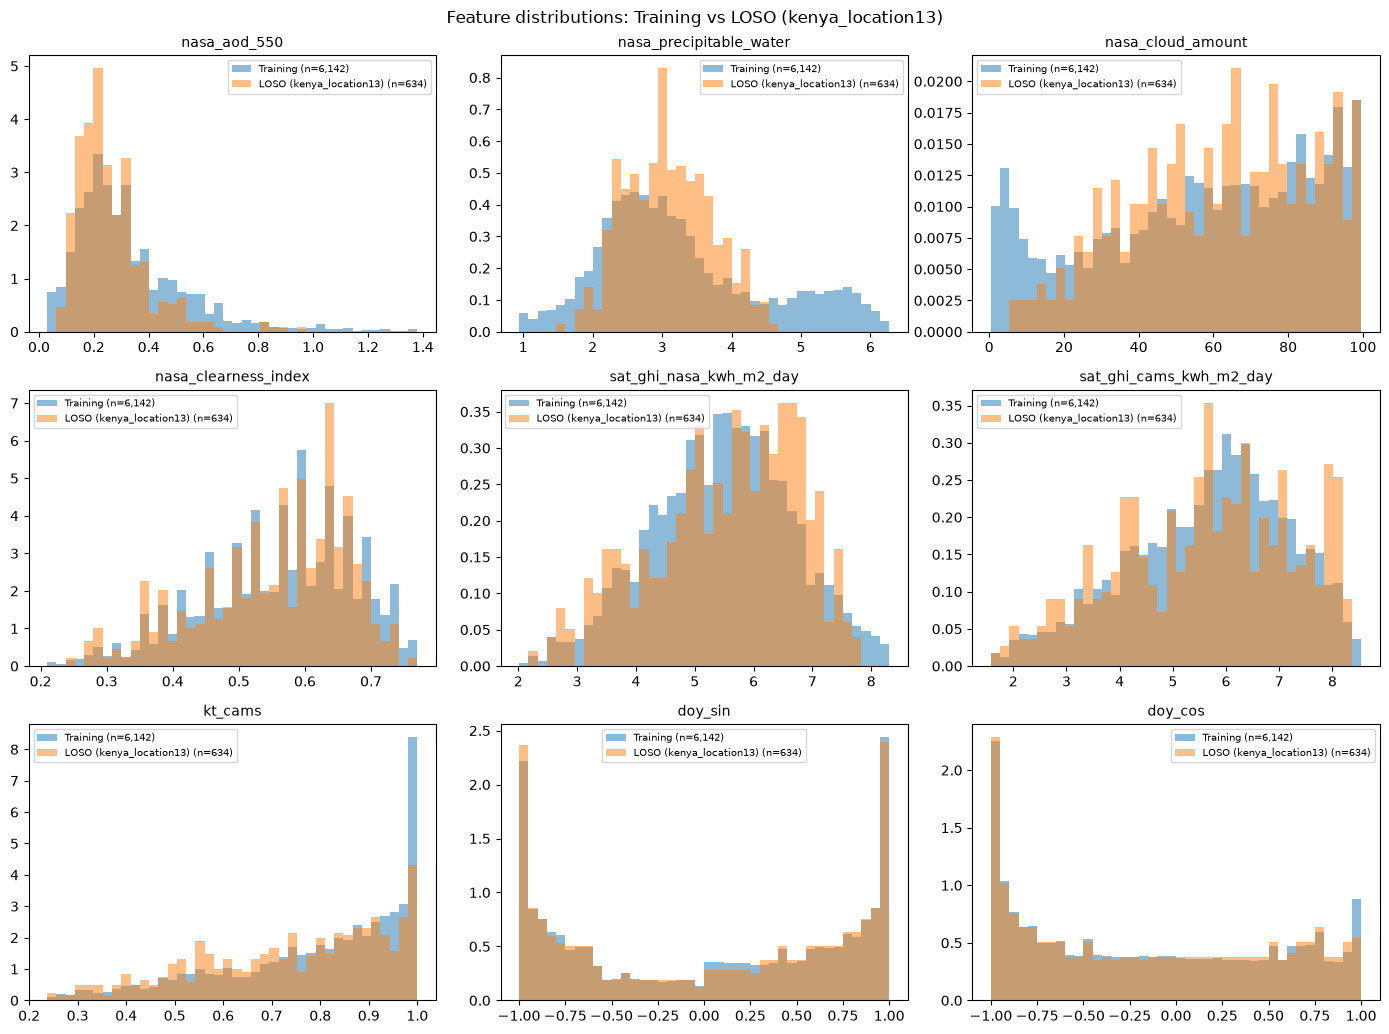

In [10]:
train_df = all_df.loc[all_df["location"] != splitter_loso.held_out_station]
plot_covariate_shift_kde(
    train_df, val_df,
    features=list(processed.feature_columns)[:9],
    train_label="Training", val_label=f"LOSO ({splitter_loso.held_out_station})",
)

### Feature importances

The helper raises a clear `TypeError` if the bundle's regressor
doesn't expose a `feature_importances` method (linear models don't);
that surfaces a bundle-vs-plot mismatch as a load-time error rather
than as silent zeros.

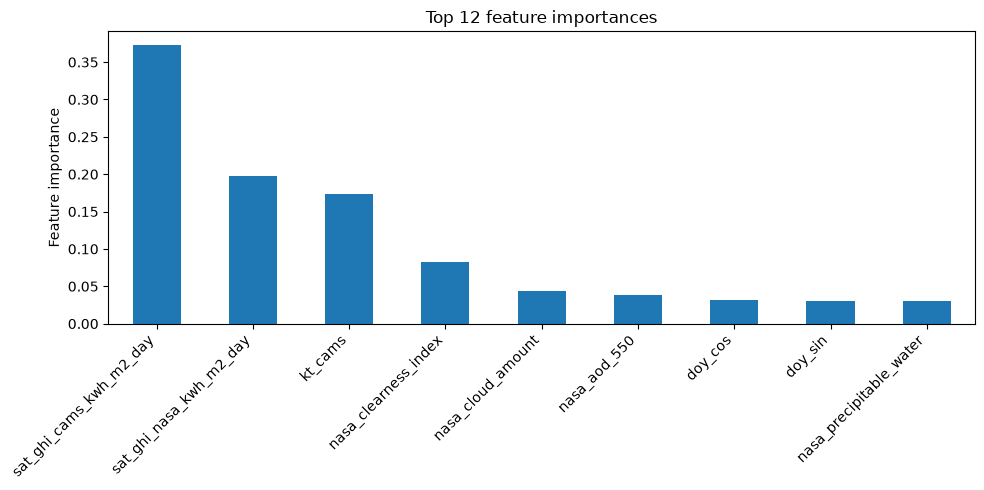

sat_ghi_cams_kwh_m2_day    0.372573
sat_ghi_nasa_kwh_m2_day    0.198225
kt_cams                    0.173943
nasa_clearness_index       0.082496
nasa_cloud_amount          0.043340
nasa_aod_550               0.037778
doy_cos                    0.031891
doy_sin                    0.030039
nasa_precipitable_water    0.029716
dtype: float64

In [11]:
plot_feature_importances_top_n(
    bundle, feature_columns=processed.feature_columns, top_n=12,
)

### Training fit — weekly time series per station

The observed series and the model's prediction are rendered with
markers; the raw NASA / CAMS satellite estimates are drawn as thin,
low-alpha background lines so the visual contrast surfaces which
series we *produced* (the model) vs. which series are *context*
(the warehouse inputs).

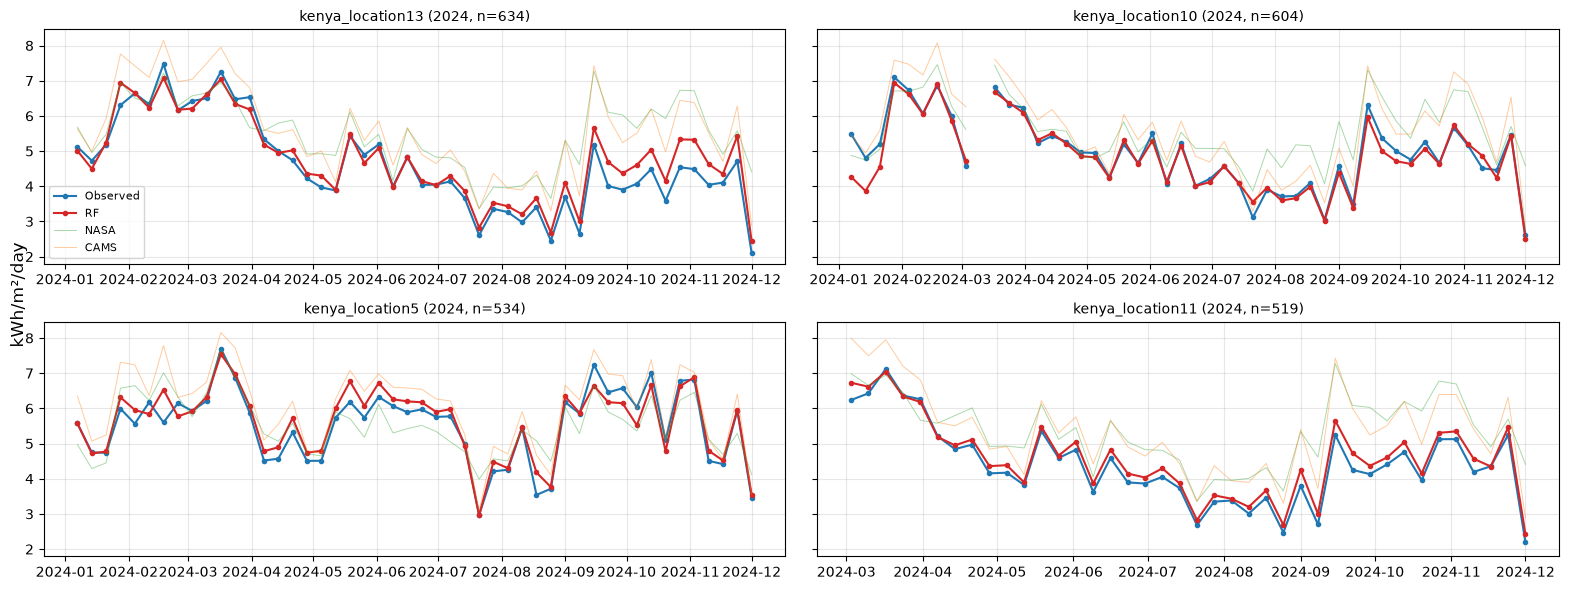

In [12]:
plot_training_fit_timeseries(
    all_df,
    observed_column="y_ghi_kwh_m2_day",
    prediction_series={"RF": "y_pred"},
    reference_series={
        "NASA": "sat_ghi_nasa_kwh_m2_day",
        "CAMS": "sat_ghi_cams_kwh_m2_day",
    },
    n_stations=4,
)

## 5 — Where to go next

* **NB 07 — `07_inference.ipynb`** — the portal-facing API:
  `load_bundle(...)` plus a `predict(lat, lon, date_range)` helper
  that does the warehouse query → preprocess → predict pipeline.
* **`inspection/` notebooks** — one question per notebook, built on
  top of `load_bundle` + the same plot helpers shown above. See the
  inventory at [`notebooks/inspection/README.md`](../inspection/README.md).
* **Paper recomputation** — for a full worked example using these
  same abstractions (with a paper-specific calibration step layered
  on top), see
  [`../papers/mukiibi_mikelson_2026/01_recomputation.ipynb`](../papers/mukiibi_mikelson_2026/01_recomputation.ipynb).

The discipline going forward:

| Change | What ripples |
|---|---|
| New splitter strategy | New `Splitter` subclass. Trainer + Evaluator signatures unchanged. |
| New metric | New `Metric` subclass. Pass it in `Evaluator(metrics=...)`. |
| New evaluation plot | New helper in `susse.evaluation.plots`. Inspection notebooks pick it up immediately. |
| Multi-bundle comparison | Build a Trainer→bundle dict and feed each bundle's predictions into Evaluator with a different label. |